Training classifier...
Epoch [1/3] Loss: 0.3408 Accuracy: 90.66%
Epoch [2/3] Loss: 0.1297 Accuracy: 96.10%
Epoch [3/3] Loss: 0.0874 Accuracy: 97.35%
Computing class prototypes...


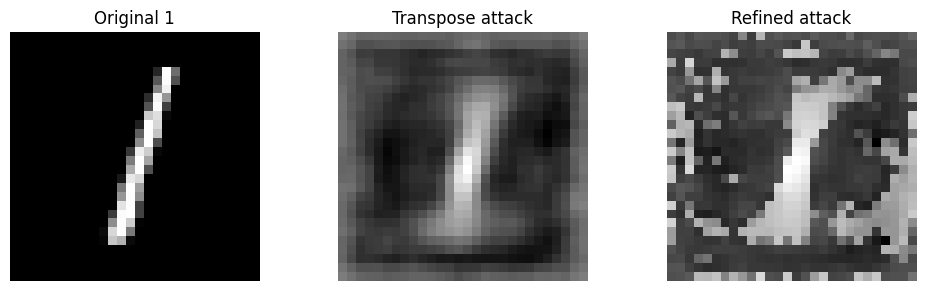

Target class: 1
Refined confidence: 0.0091
SSIM vs original - base reconstruction: 0.0513
SSIM vs original - refined reconstruction: 0.0976


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def gaussian_window(window_size, sigma, channel, device):
    coords = torch.arange(window_size, dtype=torch.float32, device=device) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()

    window_1d = g.unsqueeze(1)
    window_2d = window_1d @ window_1d.t()
    window = window_2d.expand(channel, 1, window_size, window_size).contiguous()
    return window


def ssim_torch(img1, img2, window_size=11, sigma=1.5):
    """
    Differentiable SSIM for grayscale images.
    img1, img2: [B, C, H, W], values in [0, 1]
    """
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    channel = img1.size(1)
    window = gaussian_window(window_size, sigma, channel, img1.device)

    mu1 = F.conv2d(img1, window, padding=window_size // 2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size // 2, groups=channel)

    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size // 2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size // 2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size // 2, groups=channel) - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / (
        (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    )

    return ssim_map.mean()


def sharpen_for_display(img, amount=1.0):
    """
    Light unsharp mask only for plotting.
    """
    blur = F.avg_pool2d(img, kernel_size=3, stride=1, padding=1)
    return (img + amount * (img - blur)).clamp(0.0, 1.0)


def tensor_to_show(img):
    """
    Contrast-stretch image for nicer visualization.
    """
    x = img.detach().cpu().squeeze()
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    return x.numpy()

class FCClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_model(model, train_loader, epochs=3, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {total_loss/total:.4f} "
            f"Accuracy: {100.0 * correct/total:.2f}%"
        )

def compute_class_prototypes(train_dataset):
    """
    Mean image for each digit class.
    """
    sums = torch.zeros(10, 1, 28, 28)
    counts = torch.zeros(10)

    for img, label in train_dataset:
        sums[label] += img
        counts[label] += 1

    prototypes = sums / counts.view(-1, 1, 1, 1).clamp_min(1.0)
    return prototypes

def transpose_reconstruct(model, target_class):
    """
    Reconstruct from a one-hot class vector using transposed weights.
    """
    model.eval()

    with torch.no_grad():
        y = torch.zeros(1, 10, device=device)
        y[0, target_class] = 1.0

        x = y @ model.fc3.weight
        x = F.relu(x)

        x = x @ model.fc2.weight
        x = F.relu(x)

        x = x @ model.fc1.weight
        x = torch.sigmoid(x)

        return x.view(1, 1, 28, 28)


def clean_base_reconstruction(base_img, prototype=None):
    """
    Make the raw transpose output more readable without changing it too much.
    """
    x = base_img.detach().clone()

    # Mild class prior
    if prototype is not None:
        proto = prototype.detach().to(x.device)
        x = (0.70 * x + 0.30 * proto).clamp(0.0, 1.0)

    # Gentle smoothing and contrast boost
    x = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)
    x = torch.sigmoid(2.3 * (x - 0.5))

    return x.clamp(0.0, 1.0)


def total_variation(img):
    tv_h = torch.mean(torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]))
    tv_w = torch.mean(torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]))
    return tv_h + tv_w


def binary_prior(img):
    """
    Push pixels toward 0 or 1 instead of gray noise.
    """
    return torch.mean(img * (1.0 - img))


def sobel_edges(img):
    """
    Simple edge extractor for grayscale images.
    """
    kx = torch.tensor(
        [[[-1, 0, 1],
          [-2, 0, 2],
          [-1, 0, 1]]],
        dtype=img.dtype,
        device=img.device
    ).unsqueeze(0)

    ky = torch.tensor(
        [[[-1, -2, -1],
          [ 0,  0,  0],
          [ 1,  2,  1]]],
        dtype=img.dtype,
        device=img.device
    ).unsqueeze(0)

    gx = F.conv2d(img, kx, padding=1)
    gy = F.conv2d(img, ky, padding=1)
    return torch.sqrt(gx * gx + gy * gy + 1e-8)


def refine_reconstruction_with_priors(
    model,
    init_img,
    target_class,
    prototype=None,
    steps=180,
    lr=0.0015,
    lambda_cls=0.02,
    lambda_ssim=0.65,
    lambda_proto=0.85,
    lambda_tv=0.005,
    lambda_bin=0.08,
    lambda_edge=0.12,
    lambda_base=0.20,
):
    """
    Refine the attack output while staying close to the transpose attack.
    """
    model.eval()

    eps = 1e-4
    init = init_img.detach().clamp(eps, 1.0 - eps)

    # Optimize in logit space for stability
    z = torch.log(init / (1.0 - init)).clone().detach().to(device)
    z.requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=lr)
    target = torch.tensor([target_class], device=device)

    proto = prototype.detach().to(device) if prototype is not None else None
    base_edges = sobel_edges(init_img).detach()

    if proto is not None:
        proto_edges = sobel_edges(proto).detach()
        start_ref = proto
    else:
        proto_edges = base_edges
        start_ref = init_img

    for _ in range(steps):
        optimizer.zero_grad()

        img = torch.sigmoid(z)

        logits = model(img)
        class_loss = F.cross_entropy(logits, target)

        ssim_loss = 1.0 - ssim_torch(img, start_ref)
        base_loss = F.mse_loss(img, init_img)
        proto_loss = F.mse_loss(img, proto) if proto is not None else torch.tensor(0.0, device=device)
        edge_loss = F.mse_loss(sobel_edges(img), proto_edges)
        tv_loss = total_variation(img)
        bin_loss = binary_prior(img)

        loss = (
            lambda_cls * class_loss +
            lambda_ssim * ssim_loss +
            lambda_proto * proto_loss +
            lambda_tv * tv_loss +
            lambda_bin * bin_loss +
            lambda_edge * edge_loss +
            lambda_base * base_loss
        )

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            z.clamp_(-8.0, 8.0)

    return torch.sigmoid(z).detach()

def get_sample_by_label(dataset, label):
    for img, y in dataset:
        if y == label:
            return img.unsqueeze(0), y
    return None, None

def plot_results(original_img, base_img, refined_img, digit):
    base_show = sharpen_for_display(base_img, amount=1.1)
    refined_show = sharpen_for_display(refined_img, amount=1.0)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3), tight_layout=True)

    axes[0].imshow(tensor_to_show(original_img), cmap="gray", interpolation="nearest")
    axes[0].set_title(f"Original {digit}")
    axes[0].axis("off")

    axes[1].imshow(tensor_to_show(base_show), cmap="gray", interpolation="nearest")
    axes[1].set_title("Transpose attack")
    axes[1].axis("off")

    axes[2].imshow(tensor_to_show(refined_show), cmap="gray", interpolation="nearest")
    axes[2].set_title("Refined attack")
    axes[2].axis("off")

    plt.show()

def main():
    transform = transforms.ToTensor()
    train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

    model = FCClassifier().to(device)

    print("Training classifier...")
    train_model(model, train_loader, epochs=3, lr=1e-3)

    print("Computing class prototypes...")
    prototypes = compute_class_prototypes(train_dataset).to(device)

    digit = 1

    original_img, _ = get_sample_by_label(test_dataset, digit)
    original_img = original_img.to(device)

    # Raw transpose attack
    base_raw = transpose_reconstruct(model, digit)

    # Slightly clean the base attack so it looks more like a digit
    base_img = clean_base_reconstruction(base_raw, prototypes[digit])

    # Light refinement: keep the refined image close to the base attack
    refined_img = refine_reconstruction_with_priors(
        model=model,
        init_img=base_img,
        target_class=digit,
        prototype=prototypes[digit].unsqueeze(0),
        steps=180,
        lr=0.0015,
        lambda_cls=0.02,
        lambda_ssim=0.65,
        lambda_proto=0.85,
        lambda_tv=0.005,
        lambda_bin=0.08,
        lambda_edge=0.12,
        lambda_base=0.20,
    )

    plot_results(original_img, base_img, refined_img, digit)

    with torch.no_grad():
        logits = model(refined_img)
        probs = F.softmax(logits, dim=1)

        print(f"Target class: {digit}")
        print(f"Refined confidence: {probs[0, digit].item():.4f}")

        base_ssim = ssim(
            original_img.squeeze().cpu().numpy(),
            base_img.squeeze().cpu().numpy(),
            data_range=1.0,
            channel_axis=None
        )
        ref_ssim = ssim(
            original_img.squeeze().cpu().numpy(),
            refined_img.squeeze().cpu().numpy(),
            data_range=1.0,
            channel_axis=None
        )

        print(f"SSIM vs original - base reconstruction: {base_ssim:.4f}")
        print(f"SSIM vs original - refined reconstruction: {ref_ssim:.4f}")


if __name__ == "__main__":
    main()